# Deep Sets Issue #119 Closeout Notebook

This notebook replaces `docs/deepsets_issue119/README.md` and captures the current point payload contract, manifest fields, upstream artifact usage, dropped artifacts, feature regimes, and alignment QA regeneration flow.

## Usage Notes

- Activate environment before running locally: `micromamba activate vanguard`.
- Expensive commands are guarded by `ISSUE119_RUN_EXPENSIVE=1`.
- Figure generation defaults to `analysis/deepsets_issue119/figures`.
- Legacy figure locations under `docs/deepsets_issue119/figures` are displayed if present.

In [1]:
from __future__ import annotations

import csv
import os
import subprocess
from pathlib import Path

from IPython.display import Image, Markdown, display

import build_deepsets_dataset as bdd

REPO_ROOT = Path.cwd()
if (
    not (REPO_ROOT / "build_deepsets_dataset.py").exists()
    and (REPO_ROOT / ".." / "build_deepsets_dataset.py").exists()
):
    REPO_ROOT = REPO_ROOT.parent

ANALYSIS_DIR = REPO_ROOT / "analysis" / "deepsets_issue119"
FIGURE_DIR = ANALYSIS_DIR / "figures"
LEGACY_FIGURE_DIR = REPO_ROOT / "docs" / "deepsets_issue119" / "figures"

RUN_EXPENSIVE = os.environ.get("ISSUE119_RUN_EXPENSIVE", "0") == "1"

print(f"Repo root: {REPO_ROOT}")
print(f"Analysis figure dir: {FIGURE_DIR}")
print(f"Legacy figure dir: {LEGACY_FIGURE_DIR}")
print(f"ISSUE119_RUN_EXPENSIVE={int(RUN_EXPENSIVE)}")

/home/lunad/micromamba/envs/vanguard/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repo root: /home/lunad/vanguard-issue119-closeout
Analysis figure dir: /home/lunad/vanguard-issue119-closeout/analysis/deepsets_issue119/figures
Legacy figure dir: /home/lunad/vanguard-issue119-closeout/docs/deepsets_issue119/figures
ISSUE119_RUN_EXPENSIVE=0


## Audit: Current Payload, Manifest, Upstream Inputs, and Dropped Artifacts

In [2]:
payload_fields = [
    "x (float32 [num_points, num_features])",
    "y (label scalar)",
    "case_id",
    "feature_names",
    "local_radius_mm",
    "tumor_equiv_radius_mm",
    "num_points",
    "used_fallback_nearest_points",
    "point_feature_set",
    "kinetic_timepoint_count",
]

manifest_fields = [
    "case_id",
    "set_path",
    "label",
    "dataset",
    "num_points",
    "local_radius_mm",
    "tumor_equiv_radius_mm",
    "used_fallback_nearest_points",
    "point_feature_set",
    "kinetic_timepoint_count",
]

upstream_consumed = [
    "{case_id}_skeleton_4d_exam_mask.npy (all regimes)",
    "tumor mask (all regimes; signed distance, local filtering, centroid offsets)",
    "{case_id}_skeleton_4d_exam_support_mask.npy (geometry/topology regimes only)",
    "vessel segmentation 4D NPZ phases (dynamic regime only)",
]

upstream_not_consumed = [
    "{case_id}_morphometry.json",
    "{case_id}_tumor_graph_features.json",
    "clinical DCE NIfTI phases for Deep Sets dynamic features",
]

display(Markdown("### Point payload fields"))
display(Markdown("\n".join(f"- `{field}`" for field in payload_fields)))

display(Markdown("### Manifest columns"))
display(Markdown("\n".join(f"- `{field}`" for field in manifest_fields)))

display(Markdown("### Upstream artifacts currently consumed"))
display(Markdown("\n".join(f"- {item}" for item in upstream_consumed)))

display(Markdown("### Upstream artifacts currently dropped for this path"))
display(Markdown("\n".join(f"- {item}" for item in upstream_not_consumed)))

### Point payload fields

- `x (float32 [num_points, num_features])`
- `y (label scalar)`
- `case_id`
- `feature_names`
- `local_radius_mm`
- `tumor_equiv_radius_mm`
- `num_points`
- `used_fallback_nearest_points`
- `point_feature_set`
- `kinetic_timepoint_count`

### Manifest columns

- `case_id`
- `set_path`
- `label`
- `dataset`
- `num_points`
- `local_radius_mm`
- `tumor_equiv_radius_mm`
- `used_fallback_nearest_points`
- `point_feature_set`
- `kinetic_timepoint_count`

### Upstream artifacts currently consumed

- {case_id}_skeleton_4d_exam_mask.npy (all regimes)
- tumor mask (all regimes; signed distance, local filtering, centroid offsets)
- {case_id}_skeleton_4d_exam_support_mask.npy (geometry/topology regimes only)
- vessel segmentation 4D NPZ phases (dynamic regime only)

### Upstream artifacts currently dropped for this path

- {case_id}_morphometry.json
- {case_id}_tumor_graph_features.json
- clinical DCE NIfTI phases for Deep Sets dynamic features

## Feature Regimes from `build_deepsets_dataset.py`

In [3]:
feature_regimes = [
    bdd.DEEPSETS_FEATURE_BASELINE,
    bdd.DEEPSETS_FEATURE_GEOMETRY_TOPOLOGY,
    bdd.DEEPSETS_FEATURE_GEOMETRY_TOPOLOGY_DYNAMIC,
]

for regime in feature_regimes:
    names = bdd.deepsets_point_feature_names(regime)
    display(Markdown(f"### `{regime}` ({len(names)} features)"))
    display(Markdown("\n".join(f"- `{name}`" for name in names)))

### `baseline` (1 features)

- `curvature_rad`

### `geometry_topology` (16 features)

- `signed_distance_mm`
- `abs_signed_distance_mm`
- `inside_tumor`
- `shell_0_2mm`
- `shell_2_5mm`
- `shell_5_10mm`
- `shell_ge_10mm`
- `degree`
- `is_endpoint`
- `is_chain`
- `is_bifurcation`
- `offset_x_mm`
- `offset_y_mm`
- `offset_z_mm`
- `support_radius_mm`
- `support_radius_available`

### `geometry_topology_dynamic` (27 features)

- `signed_distance_mm`
- `abs_signed_distance_mm`
- `inside_tumor`
- `shell_0_2mm`
- `shell_2_5mm`
- `shell_5_10mm`
- `shell_ge_10mm`
- `degree`
- `is_endpoint`
- `is_chain`
- `is_bifurcation`
- `offset_x_mm`
- `offset_y_mm`
- `offset_z_mm`
- `support_radius_mm`
- `support_radius_available`
- `arrival_index_norm`
- `has_arrival`
- `peak_index_norm`
- `peak_enhancement`
- `washin_slope`
- `washout_slope`
- `positive_enhancement_auc`
- `peak_rel_reference`
- `auc_rel_reference`
- `kinetic_signal_ok`
- `reference_ok`

## Optional Manifest Contract Check

In [4]:
manifest_path = REPO_ROOT / "results" / "deepsets" / "deepsets_manifest.csv"

if manifest_path.exists():
    with manifest_path.open("r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        cols = reader.fieldnames or []
    print(f"Found manifest: {manifest_path}")
    print("Columns:")
    for c in cols:
        print(f"  - {c}")
else:
    cmd = [
        "python",
        "build_deepsets_dataset.py",
        "--config",
        "configs/deepsets_ispy2.yaml",
    ]
    print(f"Manifest missing: {manifest_path}")
    print("Generate with:")
    print("PYTHONPATH=. " + " ".join(cmd))
    if RUN_EXPENSIVE:
        print("Running guarded manifest build command...")
        subprocess.run(  # noqa: S603
            cmd,
            cwd=REPO_ROOT,
            check=False,
            env={**os.environ, "PYTHONPATH": "."},
        )

Manifest missing: /home/lunad/vanguard-issue119-closeout/results/deepsets/deepsets_manifest.csv
Generate with:
PYTHONPATH=. python build_deepsets_dataset.py --config configs/deepsets_ispy2.yaml


## Alignment QA Figure Paths and Regeneration

In [5]:
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

clinical_cmd = [
    "python",
    "scripts/deepsets_alignment_check.py",
    "--case-ids",
    "ISPY2_100899,ISPY2_102011,ISPY2_102212",
    "--time-index",
    "1",
    "--out-dir",
    str(FIGURE_DIR),
]

vessel_cmd = [
    "python",
    "scripts/deepsets_alignment_check.py",
    "--case-ids",
    "ISPY2_100899",
    "--time-index",
    "1",
    "--use-vessel-segmentation-phases",
    "--out-dir",
    str(FIGURE_DIR),
]

analysis_pngs = sorted(FIGURE_DIR.glob("*.png"))
legacy_pngs = (
    sorted(LEGACY_FIGURE_DIR.glob("*.png")) if LEGACY_FIGURE_DIR.exists() else []
)

if analysis_pngs:
    print(f"Found {len(analysis_pngs)} generated figures in {FIGURE_DIR}")
else:
    print(f"No generated figures in {FIGURE_DIR}")
    print("Generate with:")
    print("PYTHONPATH=. " + " ".join(clinical_cmd))
    print("PYTHONPATH=. " + " ".join(vessel_cmd))

if RUN_EXPENSIVE and not analysis_pngs:
    print("Running guarded alignment generation commands...")
    run_env = {**os.environ, "PYTHONPATH": "."}
    subprocess.run(clinical_cmd, cwd=REPO_ROOT, check=False, env=run_env)  # noqa: S603
    subprocess.run(vessel_cmd, cwd=REPO_ROOT, check=False, env=run_env)  # noqa: S603
    analysis_pngs = sorted(FIGURE_DIR.glob("*.png"))

if legacy_pngs:
    print(
        f"Legacy figures still present in {LEGACY_FIGURE_DIR} ({len(legacy_pngs)} files)."
    )
    print("They are display-only and can be removed once regenerated into analysis/.")

No generated figures in /home/lunad/vanguard-issue119-closeout/analysis/deepsets_issue119/figures
Generate with:
PYTHONPATH=. python scripts/deepsets_alignment_check.py --case-ids ISPY2_100899,ISPY2_102011,ISPY2_102212 --time-index 1 --out-dir /home/lunad/vanguard-issue119-closeout/analysis/deepsets_issue119/figures
PYTHONPATH=. python scripts/deepsets_alignment_check.py --case-ids ISPY2_100899 --time-index 1 --use-vessel-segmentation-phases --out-dir /home/lunad/vanguard-issue119-closeout/analysis/deepsets_issue119/figures
Legacy figures still present in /home/lunad/vanguard-issue119-closeout/docs/deepsets_issue119/figures (4 files).
They are display-only and can be removed once regenerated into analysis/.


No images to display for Generated analysis figures


### Legacy docs figures (if present)

`/home/lunad/vanguard-issue119-closeout/docs/deepsets_issue119/figures/alignment_clinical_ISPY2_100899_z147_t0001.png`

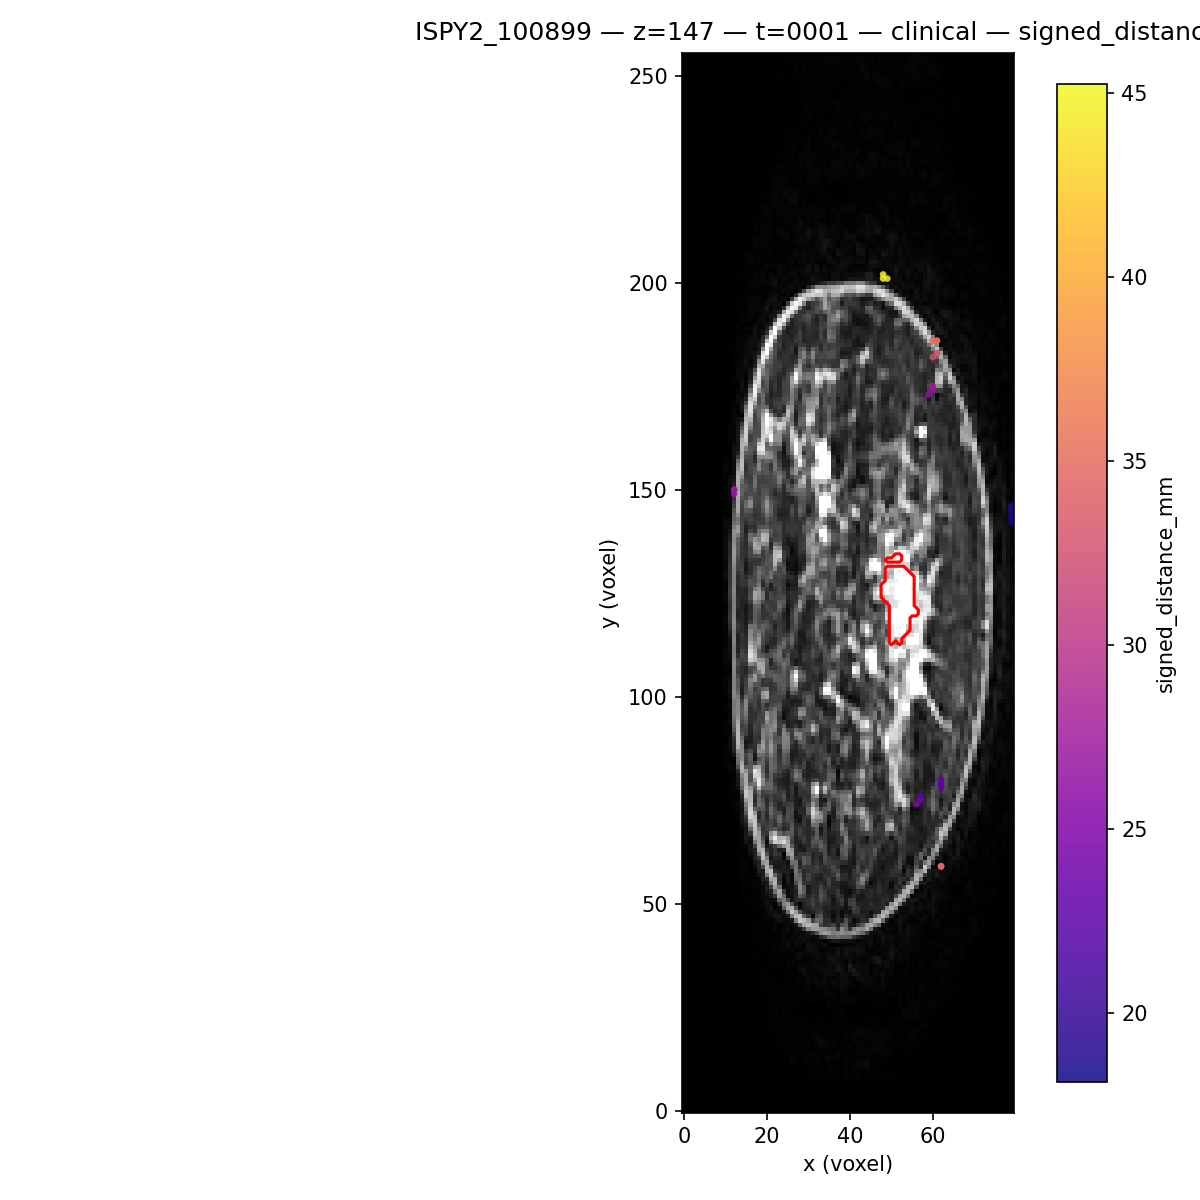

`/home/lunad/vanguard-issue119-closeout/docs/deepsets_issue119/figures/alignment_clinical_ISPY2_102011_z132_t0001.png`

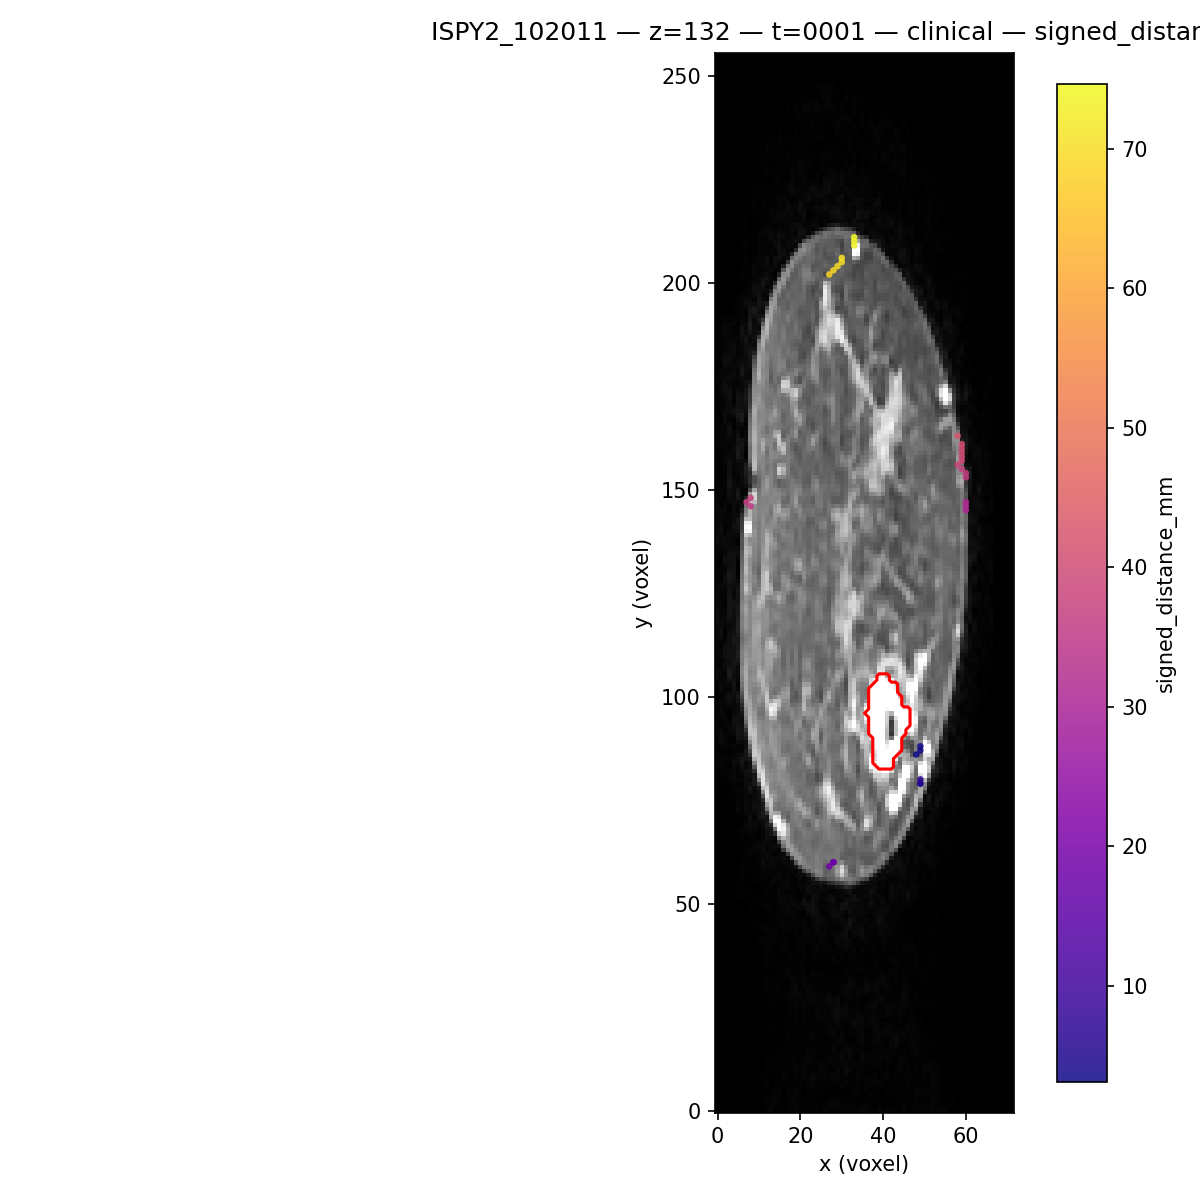

`/home/lunad/vanguard-issue119-closeout/docs/deepsets_issue119/figures/alignment_clinical_ISPY2_102212_z154_t0001.png`

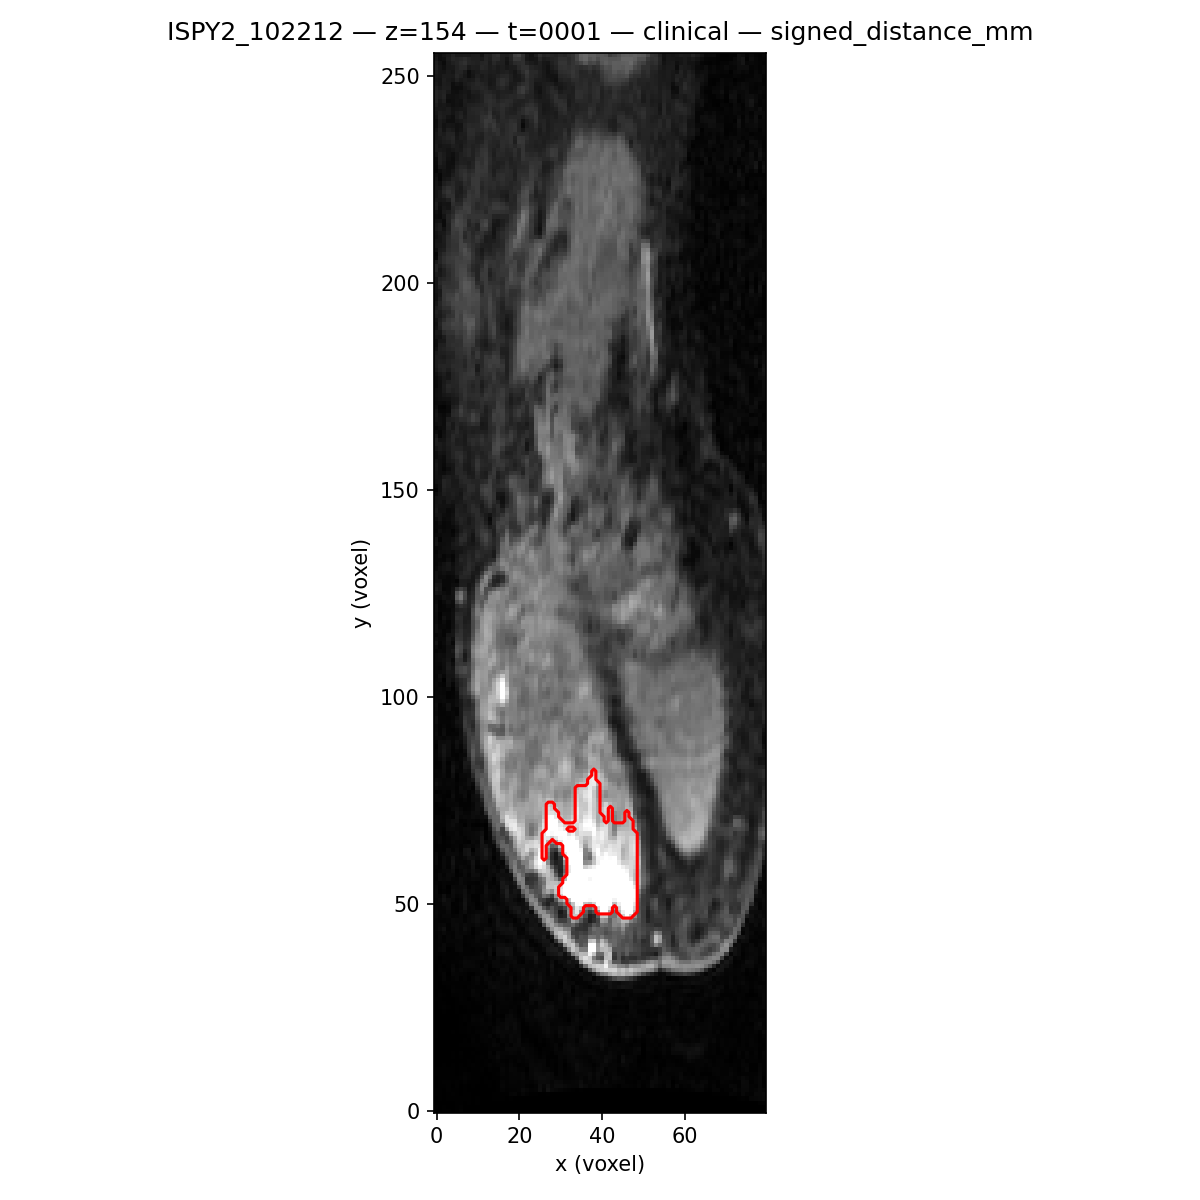

`/home/lunad/vanguard-issue119-closeout/docs/deepsets_issue119/figures/alignment_vessel_seg_ISPY2_100899_z147_t0001.png`

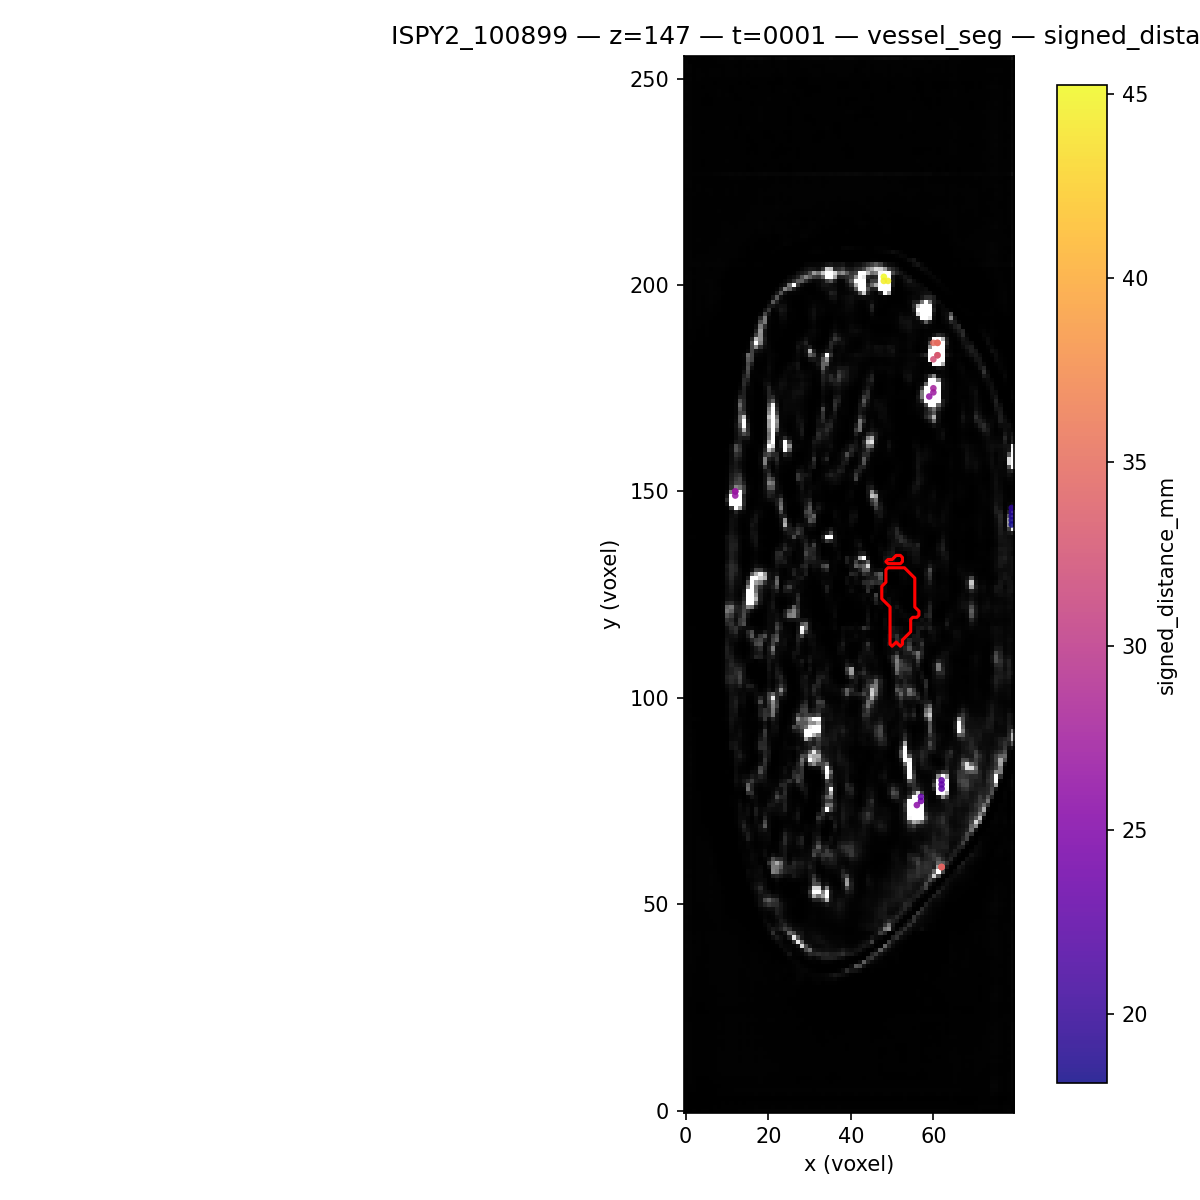

In [6]:
def _show_images(paths: list[Path], title: str, width: int = 640) -> None:
    if not paths:
        print(f"No images to display for {title}")
        return
    display(Markdown(f"### {title}"))
    for p in paths:
        display(Markdown(f"`{p}`"))
        display(Image(filename=str(p), width=width))


analysis_pngs = sorted(FIGURE_DIR.glob("*.png"))
legacy_pngs = (
    sorted(LEGACY_FIGURE_DIR.glob("*.png")) if LEGACY_FIGURE_DIR.exists() else []
)

_show_images(analysis_pngs, "Generated analysis figures")
_show_images(legacy_pngs, "Legacy docs figures (if present)")

## Reproducibility Checklist

1. Build with intended feature config and keep manifest + config snapshot.
2. Verify payload consistency (`x.shape[1] == len(feature_names)` and matching `point_feature_set`).
3. Run alignment QA overlays on representative cases.
4. Train with the same manifest using `train_deepsets.py`.
5. Record config, git SHA, and figure outputs for auditability.